# Sesión 01: EDA, calidad de datos, preprocesamiento y pipelines


**Aprendizaje de Máquina Aplicado**

**Profesor:** Marco Teran <br>
**Estudiantes:** Isis Catitza Amaya Arbelaez <br>
Santiago Alberto Rozo Silva <br>
Samuel Oviedo Paz <br>
**Fecha:** 2026


[Github](https://github.com/SamuelOviedo2003/ml-embalses-colombia.git)


In [1]:
# Configuración inicial del entorno
import sys
import warnings

warnings.filterwarnings('ignore')

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

print(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro} instalado correctamente")


Python 3.13.12 instalado correctamente


In [2]:
import sys
!"{sys.executable}" -m pip install numpy pandas matplotlib seaborn scipy scikit-learn category_encoders xgboost catboost


   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   --- ------------------------------------ 7.9/100.2 MB 51.6 MB/s eta 0:00:02
   -------- ------------------------------- 21.5/100.2 MB 60.5 MB/s eta 0:00:02
   ------------- -------------------------- 33.3/100.2 MB 60.1 MB/s eta 0:00:02
   ------------------ --------------------- 47.4/100.2 MB 62.7 MB/s eta 0:00:01
   ------------------------ --------------- 60.8/100.2 MB 63.4 MB/s eta 0:00:01
   ----------------------------- ---------- 73.7/100.2 MB 63.4 MB/s eta 0:00:01
   ---------------------------------- ----- 86.8/100.2 MB 63.5 MB/s eta 0:00:01
   --------------------------------------  100.1/100.2 MB 64.0 MB/s eta 0:00:01
   --------------------------------------  100.1/100.2 MB 64.0 MB/s eta 0:00:01
   --------------------------------------  100.1/100.2 MB 64.0 MB/s eta 0:00:01
   ---------------------------------------- 100.2/100.2 MB 50.3 MB/s  0:00:02
   ---------------------------------------- 0.0/9.9 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Iterable, Optional
from scipy import stats

print("Librerías importadas correctamente")


Librerías importadas correctamente


In [4]:
# Verificar versiones de librerías críticas
from packaging import version
from sklearn.model_selection import train_test_split
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), "Requiere scikit-learn >= 1.0.1"
print(f"scikit-learn {sklearn.__version__} instalado")


scikit-learn 1.8.0 instalado


In [5]:
def print_section(title: str, width: int = 88) -> None:
    """Print a visual section delimiter."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)


def summarize_schema(df: pd.DataFrame, target: Optional[str] = None) -> pd.DataFrame:
    """Return a compact schema summary."""
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "n_unique": df.nunique(dropna=True).values,
    })
    summary["role"] = "feature"
    if target is not None and target in summary["column"].values:
        summary.loc[summary["column"] == target, "role"] = "target"
    return summary.sort_values(["role", "missing_pct", "column"], ascending=[False, False, True]).reset_index(drop=True)


def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Return a missing-value summary sorted by missingness."""
    out = pd.DataFrame({
        "column": df.columns,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "dtype": df.dtypes.astype(str).values,
    })
    out = out.sort_values(["missing", "column"], ascending=[False, True]).reset_index(drop=True)
    return out


def detect_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Return duplicated rows."""
    dup_mask = df.duplicated(keep=False)
    return df.loc[dup_mask].copy()


def iqr_outlier_rate(series: pd.Series) -> float:
    """Return the percentage of IQR-rule outliers for a numeric series."""
    s = series.dropna()
    if s.empty:
        return 0.0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return round(mask.mean() * 100, 2)


def numeric_profile(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    """Return a robust numeric profile for selected columns."""
    rows = []
    for col in columns:
        s = df[col].dropna()
        rows.append({
            "column": col,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "max": s.max(),
            "skew": s.skew(),
            "outlier_pct_iqr": iqr_outlier_rate(df[col]),
        })
    return pd.DataFrame(rows).round(3)


def plot_missing_matrix(df: pd.DataFrame, max_rows: int = 250) -> None:
    """Visualize missingness as a compact matrix."""
    sample = df.head(max_rows)
    matrix = sample.isna().astype(int).T.values

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(matrix, aspect="auto", interpolation="nearest")
    ax.set_title("Mapa de missingness (columnas × filas)")
    ax.set_xlabel("Filas (muestra inicial)")
    ax.set_ylabel("Columnas")
    ax.set_yticks(range(len(sample.columns)))
    ax.set_yticklabels(sample.columns)
    ax.set_xticks([])
    plt.tight_layout()
    plt.show()


def plot_missing_bars(df: pd.DataFrame) -> None:
    """Bar plot of missing percentages."""
    miss = missing_summary(df)
    miss = miss[miss["missing"] > 0]
    if miss.empty:
        print("✅ No hay valores faltantes en el dataset de trabajo.")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(miss["column"], miss["missing_pct"])
    ax.set_title("Porcentaje de valores faltantes por columna")
    ax.set_ylabel("% faltante")
    ax.set_xlabel("Columna")
    ax.axhline(5, linestyle="--", linewidth=1)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


def plot_numeric_audit(df: pd.DataFrame, columns: list[str], target: str) -> None:
    """Plot histogram, boxplot, and target scatter for selected numeric columns."""
    for col in columns:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # Histograma
        axes[0].hist(df[col].dropna(), bins=40, edgecolor="black", alpha=0.8)
        axes[0].axvline(df[col].mean(), linestyle="--", linewidth=1, label=f"Media: {df[col].mean():.2f}")
        axes[0].axvline(df[col].median(), linestyle=":", linewidth=1, label=f"Mediana: {df[col].median():.2f}")
        axes[0].set_title(f"Distribución: {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")
        axes[0].legend()

        # Boxplot
        axes[1].boxplot(df[col].dropna(), vert=True, patch_artist=True)
        axes[1].set_title(f"Boxplot: {col}")
        axes[1].set_ylabel(col)

        # Relación con target
        valid = df[[col, target]].dropna()
        axes[2].scatter(valid[col], valid[target], alpha=0.2, s=10)
        axes[2].set_title(f"{col} vs {target}")
        axes[2].set_xlabel(col)
        axes[2].set_ylabel(target)

        plt.tight_layout()
        plt.show()


def plot_categorical_audit(df: pd.DataFrame, cat_col: str, target: str) -> None:
    """Audit a categorical feature."""
    counts = df[cat_col].fillna("MISSING").value_counts(dropna=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(counts.index.astype(str), counts.values)
    axes[0].set_title(f"Distribución de categorías: {cat_col}")
    axes[0].set_xlabel(cat_col)
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    grouped = df[[cat_col, target]].copy()
    grouped[cat_col] = grouped[cat_col].fillna("MISSING")
    category_order = counts.index.astype(str).tolist()

    data_for_box = [
        grouped.loc[grouped[cat_col].astype(str) == level, target].dropna().values
        for level in category_order
    ]
    axes[1].boxplot(data_for_box, labels=category_order, patch_artist=True)
    axes[1].set_title(f"{target} por categoría: {cat_col}")
    axes[1].set_xlabel(cat_col)
    axes[1].set_ylabel(target)
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df: pd.DataFrame, columns: list[str]) -> None:
    """Simple correlation heatmap using matplotlib only."""
    corr = df[columns].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title("Matriz de correlación")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def quick_interpretation(df: pd.DataFrame, target: str, numeric_cols: list[str]) -> None:
    """Print short interpretation cues after EDA."""
    print_section("LECTURA RÁPIDA DEL EDA")
    print(f"- Filas: {df.shape[0]:,}")
    print(f"- Columnas: {df.shape[1]}")
    print(f"- Target: {target}")
    print(f"- Variables numéricas: {len(numeric_cols)}")
    print(f"- Variables categóricas: {df.select_dtypes(exclude=[np.number]).shape[1]}")
    print(f"- Valores faltantes totales: {int(df.isna().sum().sum())}")
    print(f"- Filas duplicadas exactas: {int(df.duplicated().sum())}")


In [6]:
def plot_cross_corr(df, feature, target, max_lag=30):
    lags = range(0, max_lag)
    corrs = [
        df[target].corr(df[feature].shift(lag))
        for lag in lags
    ]

    plt.figure(figsize=(8,4))
    plt.plot(lags, corrs)
    plt.title(f"Cross-correlation: {feature} vs {target}")
    plt.xlabel("Lag (días)")
    plt.ylabel("Correlación")
    plt.axhline(0)
    plt.show()


In [7]:
def plot_lag_scatter(df, feature, target, lag=7):
    plt.figure(figsize=(5,5))
    plt.scatter(df[feature].shift(lag), df[target], alpha=0.3)
    plt.xlabel(f"{feature} (lag {lag})")
    plt.ylabel(target)
    plt.title(f"{feature}_lag{lag} vs {target}")
    plt.show()


In [8]:
def plot_time_series(df, feature, embalse):
    data = df[df["CodigoEmbalse"] == embalse]

    plt.figure(figsize=(10,4))
    plt.plot(data["Fecha"], data["reserva_pct"], label="reserva")
    plt.plot(data["Fecha"], data[feature], label=feature, alpha=0.7)
    plt.legend()
    plt.title(f"{feature} vs reserva - {embalse}")
    plt.show()


In [9]:
import seaborn as sns

def lag_corr_matrix(df, feature, target, max_lag=15):
    data = {
        f"{feature}_lag_{lag}": df[feature].shift(lag)
        for lag in range(1, max_lag)
    }
    lag_df = pd.DataFrame(data)
    lag_df[target] = df[target]

    corr = lag_df.corr()

    plt.figure(figsize=(6,6))
    sns.heatmap(corr[[target]].sort_values(by=target, ascending=False), annot=True, cmap="coolwarm")
    plt.title(f"Lag correlation: {feature}")
    plt.show()


In [10]:
# Ruta al dataset
data_path = Path("Datasets/dataset_final.csv")

# Cargar dataset
embalses = pd.read_csv(data_path)

# Definir target
TARGET = "reserva_pct" 

print(f"✅ Dataset cargado desde: {data_path}")
print(f"✅ Shape: {embalses.shape[0]:,} filas × {embalses.shape[1]} columnas")


✅ Dataset cargado desde: Datasets\dataset_final.csv
✅ Shape: 99,838 filas × 18 columnas


In [11]:
embalses = embalses[embalses['CodigoEmbalse'] != 'AGREGADO_SIN']

embalses["Fecha"] = pd.to_datetime(embalses["Fecha"])

embalses = embalses[embalses["Fecha"] < "2025-01-01"]

# Verificar que se eliminó
#print(embalses['CodigoEmbalse'].value_counts())
print(embalses['CodigoEmbalse'].unique())
#print(f"\nRegistros restantes: {len(embalses)}")
#print(embalses[embalses["CodigoEmbalse"] == "AGREGADO"])


<StringArray>
['AGREGADO_BOGOTA',        'ALTOANCH',         'BETANIA',         'CALIMA1',
           'CHUZA',        'ESMERALD',          'GUAVIO',           'MIEL1',
        'MIRAFLOR',            'MUNA',           'PENOL',          'PLAYAS',
          'PORCE2',          'PORCE3',           'PRADO',        'PUNCHINA',
        'RIOGRAN2',        'SALVAJIN',        'SANLOREN',        'TRONERAS',
           'URRA1',        'SOGAMOSO',        'ELQUIMBO',         'ITUANGO']
Length: 24, dtype: str


In [12]:
print_section("PRIMERA INSPECCIÓN")

display(embalses.head())

print("\nTipos de datos:")
display(embalses.dtypes.to_frame(name="dtype").T)

print("\nDescripción numérica rápida:")
display(embalses.describe(include=[np.number]).T)



                                   PRIMERA INSPECCIÓN                                   


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct,aportes_masa,media_historica_masa,aportes_vs_media_pct,t2m,u10,v10,msl,sst_nino12_proxy,oni_anom,tp,ro,sro,swvl1,wind_speed
0,2013-01-01,AGREGADO_BOGOTA,Centro,78.07,230740000.0,337530000.0,68.361331,15.080780,-1.319832,0.388092,1016.10016,23.663086,-0.29,0.000596,0.024259,0.000089,0.278295,1.375708
1,2013-01-01,ALTOANCH,Valle,42.61,131910000.0,251100000.0,52.532855,25.506561,0.026604,0.779938,1009.99140,23.663086,-0.29,0.550508,0.380278,0.037938,0.500181,0.780391
2,2013-01-01,BETANIA,Centro,79.99,230740000.0,337530000.0,68.361331,22.812714,1.079582,0.876373,1011.49200,23.663086,-0.29,0.000477,0.004232,0.000000,0.327062,1.390513
3,2013-01-01,CALIMA1,Valle,75.15,131910000.0,251100000.0,52.532855,18.804901,0.891106,-0.748627,1013.66266,23.663086,-0.29,0.626683,0.474691,0.307947,0.470689,1.163835
4,2013-01-01,CHUZA,Oriente,64.33,29590000.0,37190000.0,79.564399,12.801971,-2.053474,0.732819,1016.85516,23.663086,-0.29,0.000119,0.006855,0.000030,0.269834,2.180317



Tipos de datos:


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct,aportes_masa,media_historica_masa,aportes_vs_media_pct,t2m,u10,v10,msl,sst_nino12_proxy,oni_anom,tp,ro,sro,swvl1,wind_speed
dtype,datetime64[us],str,str,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64



Descripción numérica rápida:


,count,mean,std,min,25%,50%,75%,max
reserva_pct,99838.0,6.231616e+01,2.512248e+01,-1.850000,4.417000e+01,6.324000e+01,8.253000e+01,1.243900e+02
aportes_masa,99838.0,4.997932e+08,5.372208e+08,0.000000,1.821900e+08,3.200150e+08,6.171145e+08,5.932676e+09
media_historica_masa,99838.0,5.416340e+08,4.693334e+08,0.000000,2.283700e+08,3.613300e+08,7.372700e+08,2.871090e+09
aportes_vs_media_pct,99793.0,9.165024e+01,4.788645e+01,5.807358,6.112072e+01,8.172243e+01,1.105709e+02,1.251948e+03
t2m,99838.0,2.089873e+01,4.363144e+00,10.396088,1.766138e+01,2.015091e+01,2.464609e+01,3.275363e+01
u10,99838.0,-8.812153e-02,6.285297e-01,-3.179215,-4.283237e-01,-8.707809e-02,2.663450e-01,2.942589e+00
v10,99838.0,9.488457e-02,5.500325e-01,-2.124630,-2.386131e-01,5.714416e-02,3.825474e-01,3.199093e+00
msl,99838.0,1.013707e+03,2.676457e+00,1004.449500,1.011634e+03,1.013731e+03,1.015697e+03,1.022905e+03
sst_nino12_proxy,99838.0,2.333453e+01,2.064041e+00,18.682465,2.174106e+01,2.320749e+01,2.469922e+01,2.893881e+01
oni_anom,99838.0,1.764303e-01,8.871250e-01,-1.200000,-5.000000e-01,0.000000e+00,6.500000e-01,2.750000e+00


In [13]:
# Definir target correcto
TARGET = "reserva_pct"  # según tu tabla

# Ejecutar resumen de esquema
schema_df = summarize_schema(embalses, target=TARGET)

print_section("SCHEMA SUMMARY")
display(schema_df)



                                     SCHEMA SUMMARY                                     


,column,dtype,non_null,missing,missing_pct,n_unique,role
0,reserva_pct,float64,99838,0,0.00,11028,target
1,aportes_vs_media_pct,float64,99793,45,0.05,26239,feature
2,CodigoEmbalse,str,99838,0,0.00,24,feature
3,Fecha,datetime64[us],99838,0,0.00,4383,feature
4,RegionHidrologica,str,99838,0,0.00,6,feature
5,aportes_masa,float64,99838,0,0.00,24480,feature
6,media_historica_masa,float64,99838,0,0.00,854,feature
7,msl,float64,99838,0,0.00,48968,feature
8,oni_anom,float64,99838,0,0.00,109,feature
9,ro,float64,99838,0,0.00,13449,feature


In [14]:
print_section("SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES")

feature_cols = [col for col in embalses.columns if col != TARGET]
numeric_cols = embalses[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = embalses[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Target: {TARGET}")
print(f"Número de features: {len(feature_cols)}")
print(f"Features numéricas: {numeric_cols}")
print(f"Features categóricas: {categorical_cols}")



                       SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES                        
Target: reserva_pct
Número de features: 17
Features numéricas: ['aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 't2m', 'u10', 'v10', 'msl', 'sst_nino12_proxy', 'oni_anom', 'tp', 'ro', 'sro', 'swvl1', 'wind_speed']
Features categóricas: ['Fecha', 'CodigoEmbalse', 'RegionHidrologica']


In [15]:
print_section("INTEGRIDAD BÁSICA")

duplicated_rows = detect_duplicate_rows(embalses)
print(f"Filas duplicadas exactas: {embalses.duplicated().sum()}")

low_cardinality_numeric = [
    col for col in numeric_cols
    if embalses[col].nunique(dropna=True) <= 10
]
print(f"Variables numéricas con baja cardinalidad: {low_cardinality_numeric}")

high_cardinality_categorical = [
    col for col in categorical_cols
    if embalses[col].nunique(dropna=True) > 20
]
print(f"Variables categóricas con cardinalidad alta: {high_cardinality_categorical}")

if not duplicated_rows.empty:
    print("\nEjemplo de duplicados detectados:")
    display(duplicated_rows.head())



                                   INTEGRIDAD BÁSICA                                    


Filas duplicadas exactas: 0
Variables numéricas con baja cardinalidad: []
Variables categóricas con cardinalidad alta: ['Fecha', 'CodigoEmbalse']


In [16]:
miss_df = missing_summary(embalses)
print_section("RESUMEN DE VALORES FALTANTES")
display(miss_df)



                              RESUMEN DE VALORES FALTANTES                              


,column,missing,missing_pct,dtype
0,aportes_vs_media_pct,45,0.05,float64
1,CodigoEmbalse,0,0.00,str
2,Fecha,0,0.00,datetime64[us]
3,RegionHidrologica,0,0.00,str
4,aportes_masa,0,0.00,float64
5,media_historica_masa,0,0.00,float64
6,msl,0,0.00,float64
7,oni_anom,0,0.00,float64
8,reserva_pct,0,0.00,float64
9,ro,0,0.00,float64


In [17]:
selected_numeric_for_audit = [
    col for col in [
        "aportes_masa",
        "media_historica_masa",
        "aportes_vs_media_pct",
        "t2m",
        "u10",
        "v10",
        "msl",
        "sst_nino",
        "tp",
        "ro",
        "sro",
        "swvl1",
        "wind_speed"
    ]
    if col in embalses.columns
]

numeric_profile_df = numeric_profile(embalses, selected_numeric_for_audit)

print_section("PERFIL NUMÉRICO ROBUSTO (FEATURES)")
display(numeric_profile_df)



                           PERFIL NUMÉRICO ROBUSTO (FEATURES)                           


,column,mean,median,std,min,q1,q3,max,skew,outlier_pct_iqr
0,aportes_masa,4.997932e+08,3.200150e+08,5.372208e+08,0.000,1.821900e+08,6.171145e+08,5.932676e+09,2.847,7.76
1,media_historica_masa,5.416340e+08,3.613300e+08,4.693334e+08,0.000,2.283700e+08,7.372700e+08,2.871090e+09,1.685,3.62
2,aportes_vs_media_pct,9.165000e+01,8.172200e+01,4.788600e+01,5.807,6.112100e+01,1.105710e+02,1.251948e+03,3.831,3.92
3,t2m,2.089900e+01,2.015100e+01,4.363000e+00,10.396,1.766100e+01,2.464600e+01,3.275400e+01,0.095,0.00
4,u10,-8.800000e-02,-8.700000e-02,6.290000e-01,-3.179,-4.280000e-01,2.660000e-01,2.943000e+00,-0.215,4.05
5,v10,9.500000e-02,5.700000e-02,5.500000e-01,-2.125,-2.390000e-01,3.830000e-01,3.199000e+00,0.453,3.22
6,msl,1.013707e+03,1.013731e+03,2.676000e+00,1004.450,1.011634e+03,1.015697e+03,1.022905e+03,0.035,0.03
7,tp,2.780000e-01,1.030000e-01,5.240000e-01,0.000,2.100000e-02,3.320000e-01,1.623800e+01,6.800,8.62
8,ro,1.620000e-01,6.500000e-02,4.100000e-01,0.000,1.900000e-02,1.670000e-01,1.659900e+01,11.944,8.99
9,sro,7.900000e-02,1.200000e-02,2.280000e-01,0.000,1.000000e-03,6.900000e-02,1.078900e+01,12.340,12.17


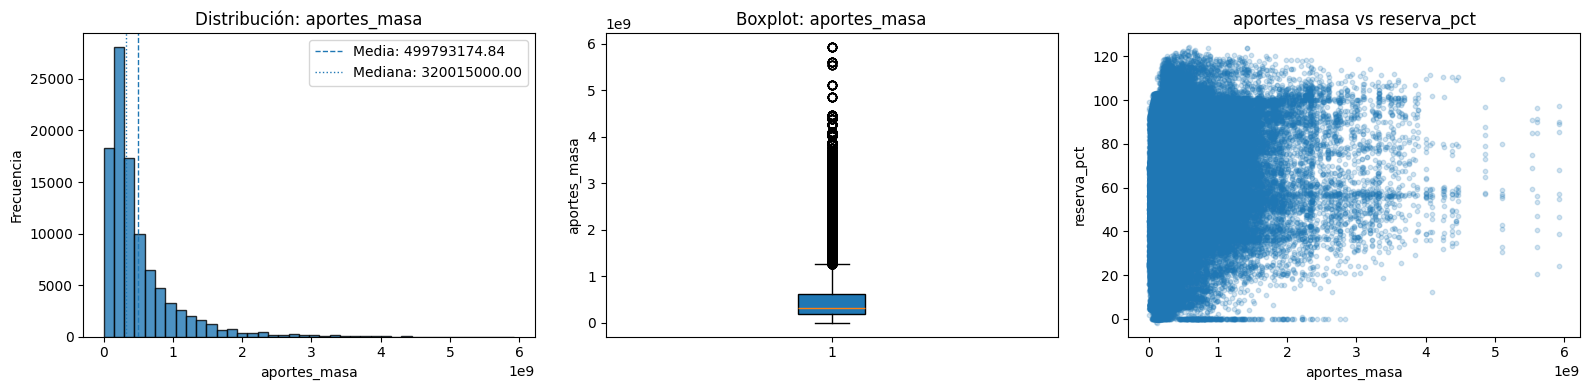

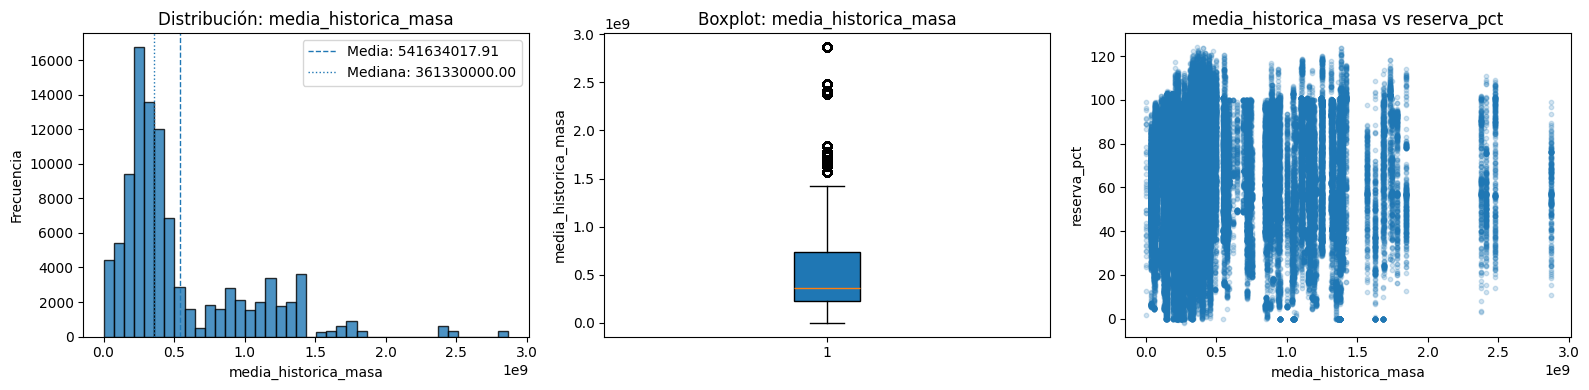

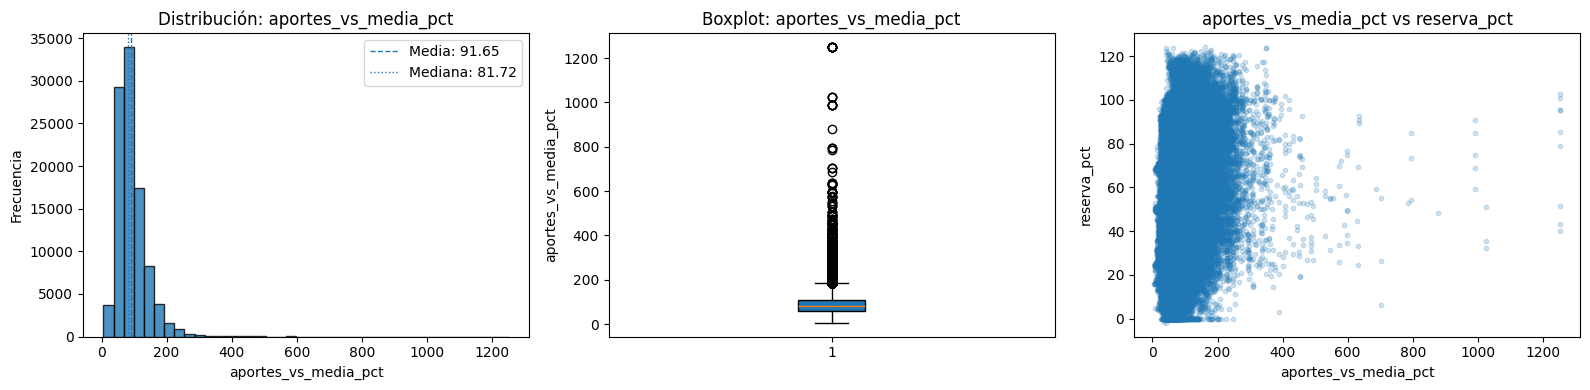

In [18]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "aportes_masa",
            "media_historica_masa",
            "aportes_vs_media_pct"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


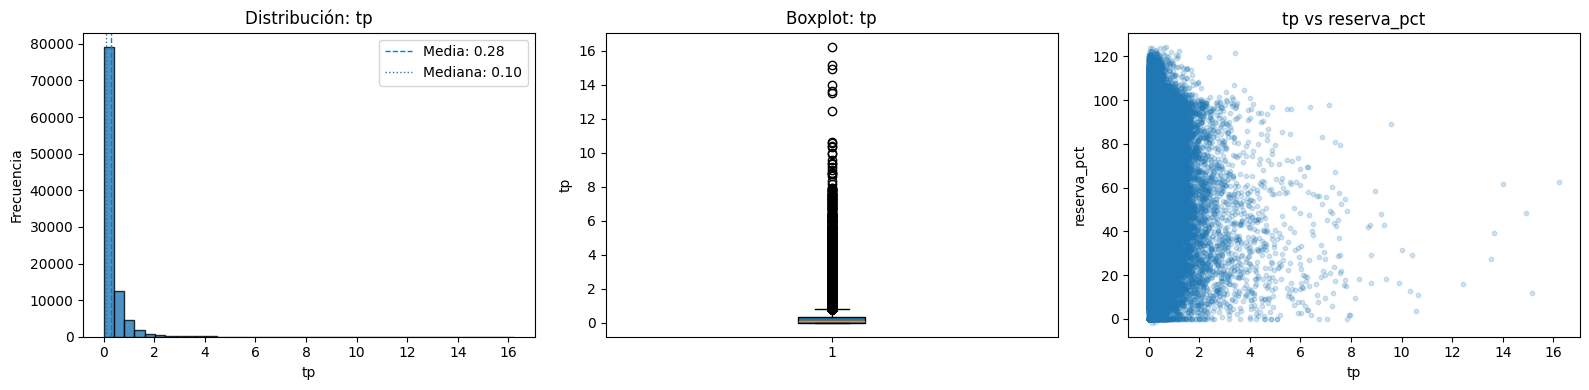

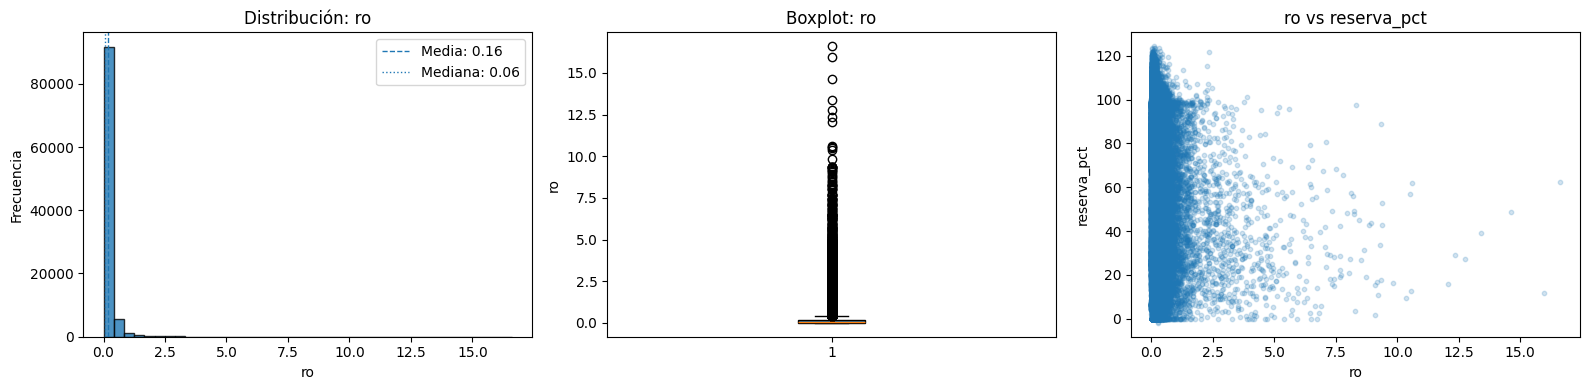

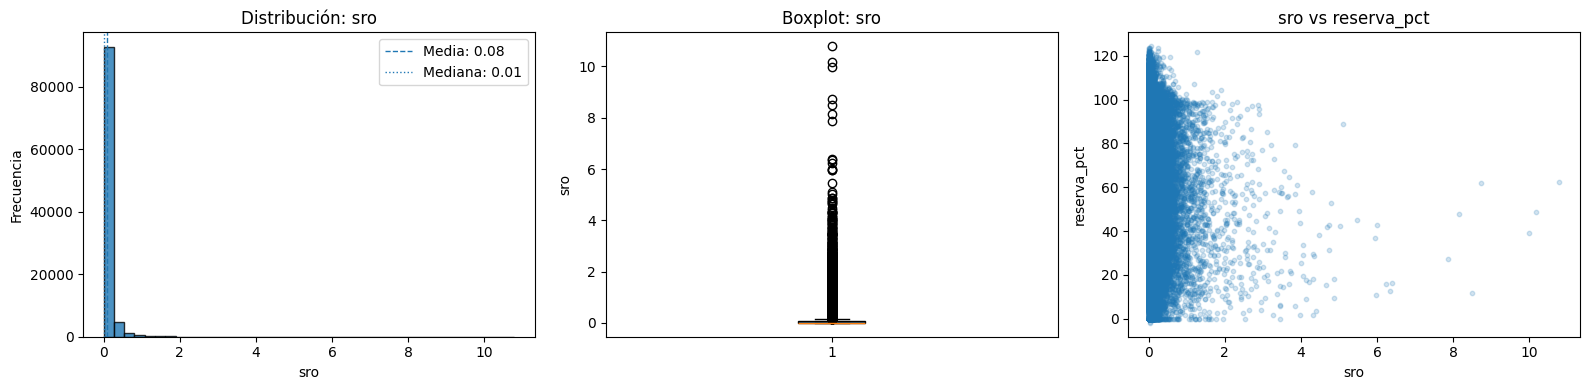

In [19]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "tp",
            "ro",
            "sro"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


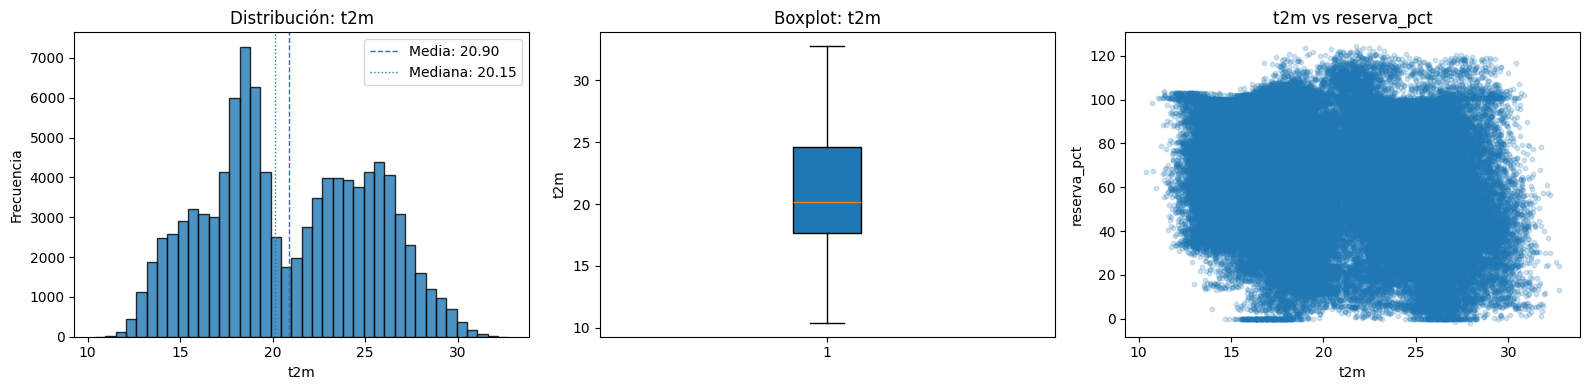

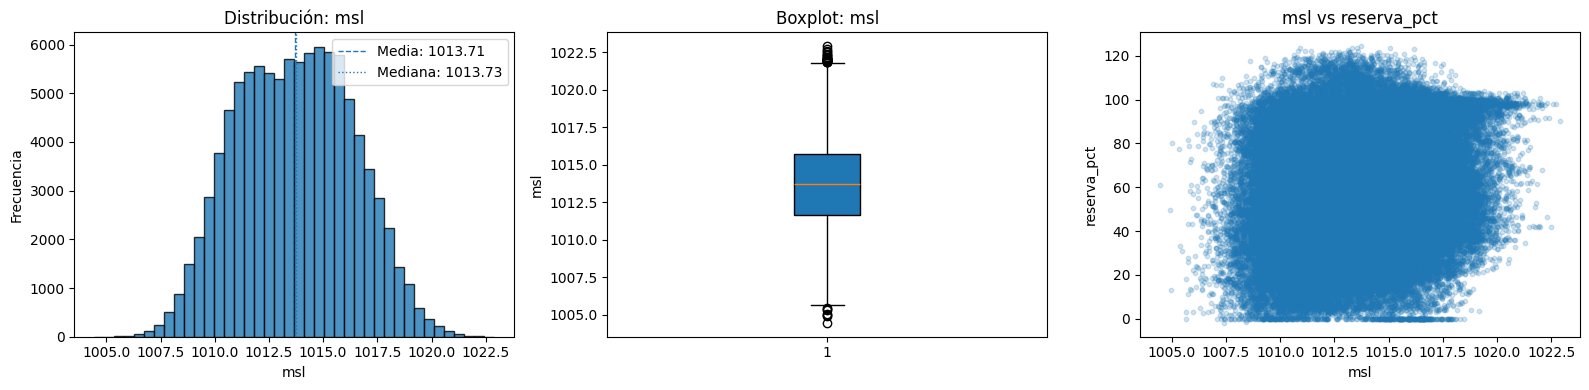

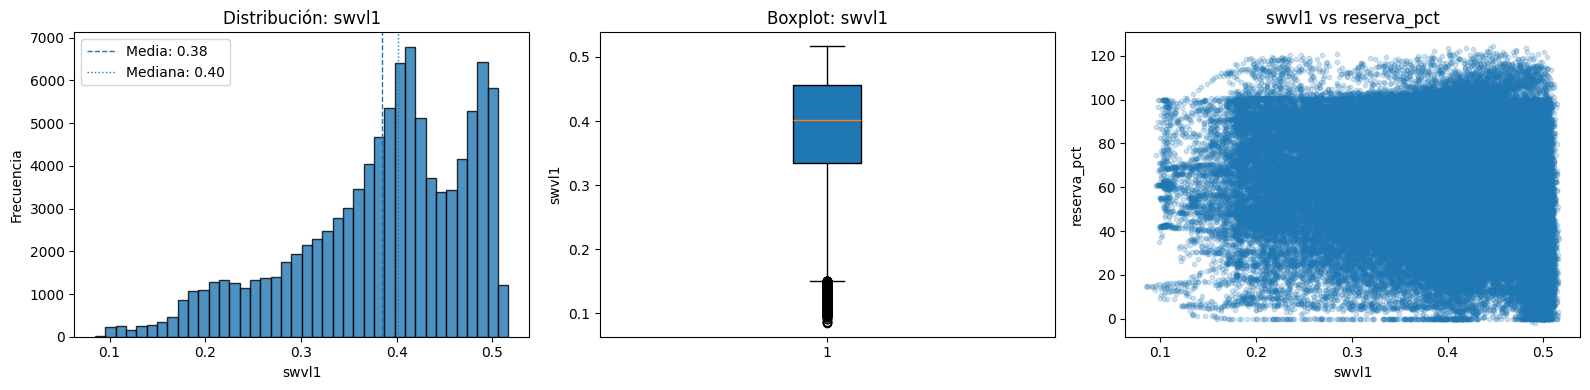

In [20]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "t2m",
            "msl",
            "swvl1"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


In [21]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "sst_nino"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


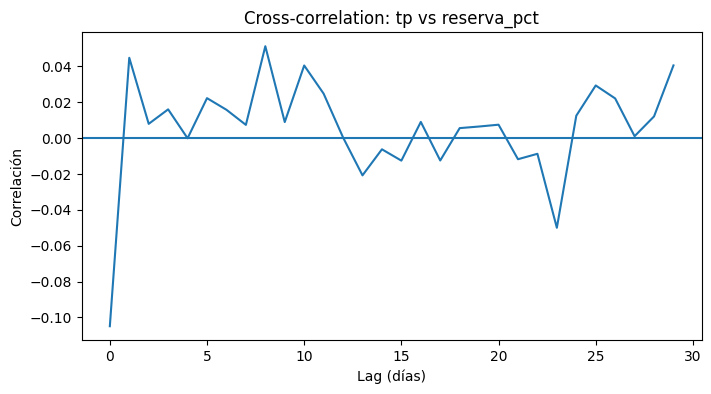

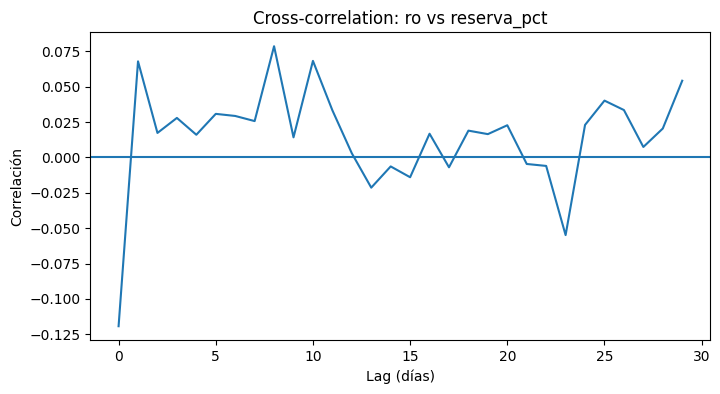

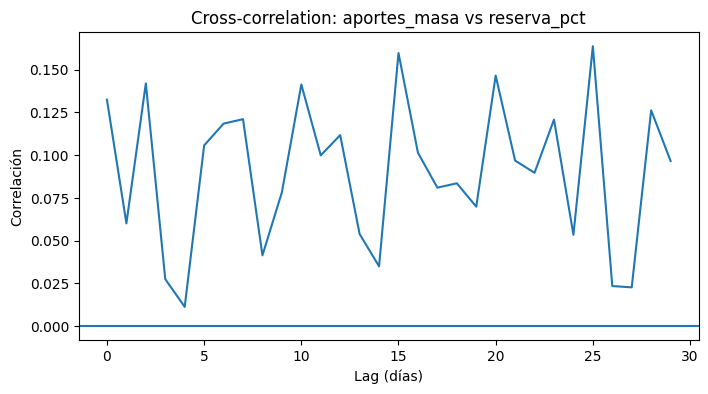

In [22]:
plot_cross_corr(embalses, "tp", "reserva_pct")
plot_cross_corr(embalses, "ro", "reserva_pct")
plot_cross_corr(embalses, "aportes_masa", "reserva_pct")


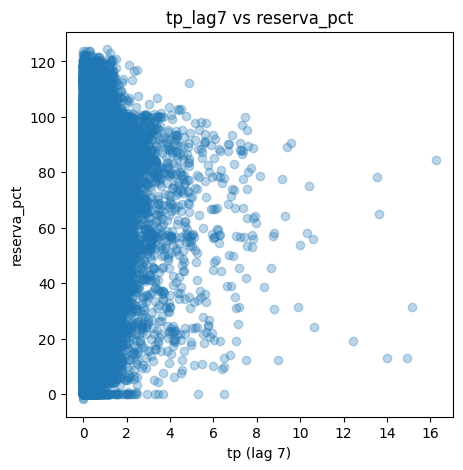

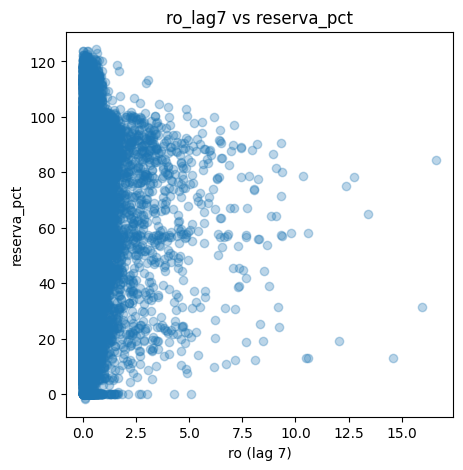

In [23]:
plot_lag_scatter(embalses, "tp", "reserva_pct", lag=7)
plot_lag_scatter(embalses, "ro", "reserva_pct", lag=7)


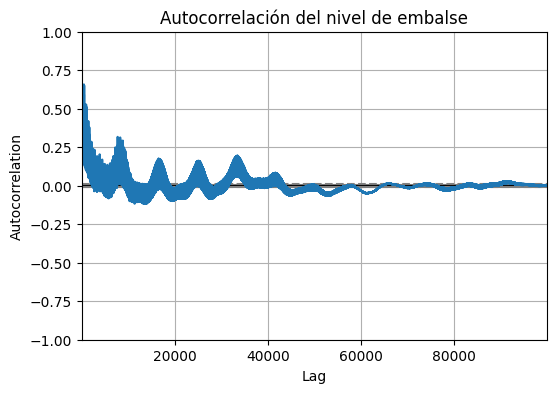

In [24]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(6,4))
autocorrelation_plot(embalses["reserva_pct"])
plt.title("Autocorrelación del nivel de embalse")
plt.show()


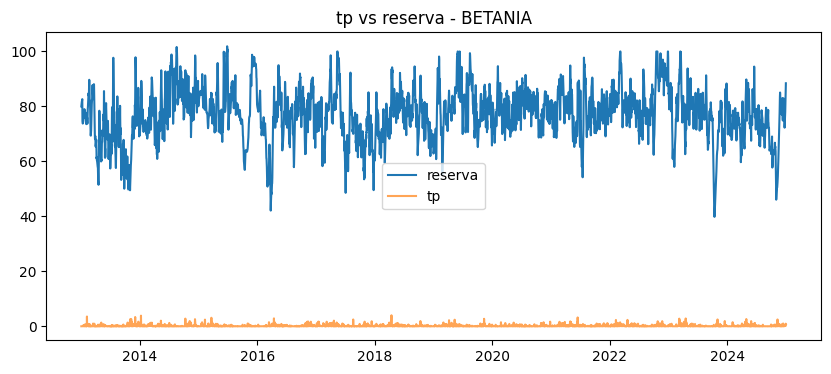

In [25]:
plot_time_series(embalses, "tp", "BETANIA")


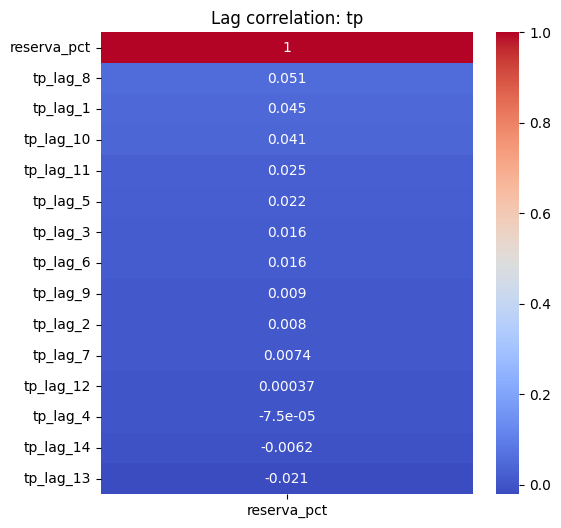

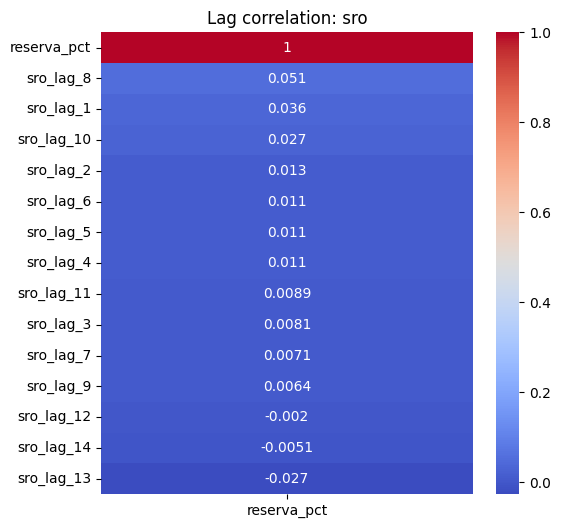

In [26]:
lag_corr_matrix(embalses, "tp", "reserva_pct")
lag_corr_matrix(embalses, "sro", "reserva_pct")


In [27]:
quick_interpretation(embalses, target=TARGET, numeric_cols=numeric_cols)



                                 LECTURA RÁPIDA DEL EDA                                 
- Filas: 99,838
- Columnas: 18
- Target: reserva_pct
- Variables numéricas: 14
- Variables categóricas: 3
- Valores faltantes totales: 45
- Filas duplicadas exactas: 0


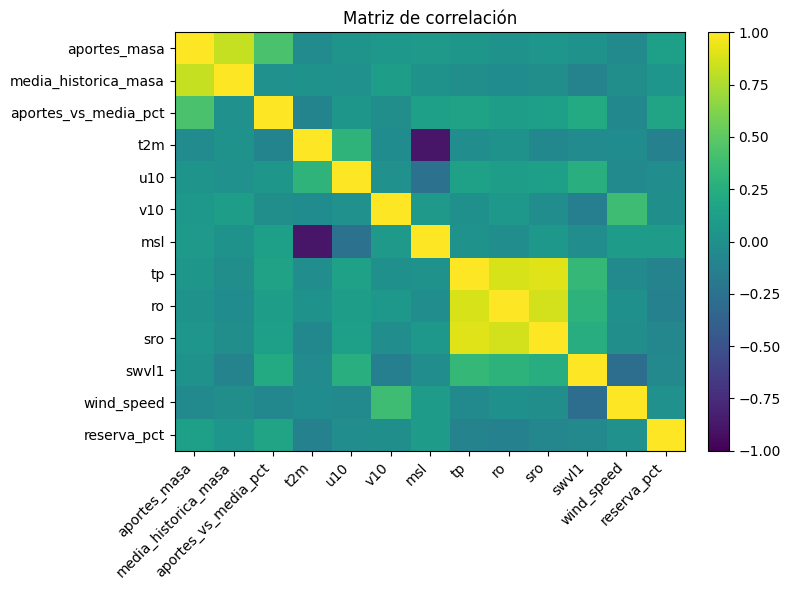

In [28]:
# Variables numéricas a analizar
selected_numeric_for_audit = [
    "aportes_masa",
    "media_historica_masa",
    "aportes_vs_media_pct",
    "t2m",
    "u10",
    "v10",
    "msl",
    "sst_nino",
    "tp",
    "ro",
    "sro",
    "swvl1",
    "wind_speed",
    "reserva_pct"
]
 
# Filtrar solo columnas existentes
selected_numeric_for_audit = [
    col for col in selected_numeric_for_audit
    if col in embalses.columns
]
 
# Invocar función
plot_correlation_heatmap(
    embalses,
    selected_numeric_for_audit
)


In [29]:
target_corr = (
    embalses[selected_numeric_for_audit]
    .corr(numeric_only=True)[TARGET]
    .sort_values(ascending=False)
    .drop(TARGET)
    .to_frame(name="corr_with_target")
)

print_section("CORRELACIÓN CON EL TARGET")
display(target_corr)



                               CORRELACIÓN CON EL TARGET                                


,corr_with_target
aportes_vs_media_pct,0.165469
aportes_masa,0.132386
msl,0.108525
media_historica_masa,0.054126
wind_speed,0.014270
v10,-0.007028
u10,-0.015649
swvl1,-0.055997
sro,-0.076776
tp,-0.104895


## Outliers


In [30]:
embalses = embalses.query("reserva_pct > 0")


## Split


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from category_encoders import BinaryEncoder


In [32]:
SEED = 72


In [33]:
embalses = embalses.sort_values("Fecha")
base_feature_cols = [col for col in embalses.columns if col != TARGET]

X_full = embalses[base_feature_cols].copy()
y_full = embalses[TARGET].copy()

split_idx = int(len(X_full) * 0.8)

X_train_raw = X_full.iloc[:split_idx]
X_test_raw  = X_full.iloc[split_idx:]

y_train = y_full.iloc[:split_idx]
y_test  = y_full.iloc[split_idx:]

print_section("PARTICIÓN DE DATOS")
print(f"Train shape: {X_train_raw.shape}")
print(f"Test shape:  {X_test_raw.shape}")
print(f"Target mean (train): {y_train.mean():,.3f}")
print(f"Target mean (test):  {y_test.mean():,.3f}")



                                   PARTICIÓN DE DATOS                                   
Train shape: (79563, 17)
Test shape:  (19891, 17)
Target mean (train): 62.802
Target mean (test):  61.575


## Feature engineering


In [50]:
def rolling_mean(series, window):
    return series.shift(1).rolling(window, min_periods=1).mean()

def rolling_std(series, window):
    return series.shift(1).rolling(window, min_periods=2).std()

def add_engineered_features(pd: pd.DataFrame) -> pd.DataFrame:
    """Add simple deterministic engineered features."""
    out = pd.copy()

    for lag in [1, 7, 14]:
        out[f"aportes_lag{lag}"] = out.groupby("CodigoEmbalse")["aportes_masa"].shift(lag)


    out["deficit_aportes"] = out["media_historica_masa"] - out["aportes_masa"]   # déficit absoluto
    out["deficit_pct"]     = (out["deficit_aportes"] / out["media_historica_masa"].replace(0, np.nan)) * 100

    # Diferencia entre escorrentía total y superficial (escorrentía subsuperficial)
    out["ro_subsuperficial"] = out["ro"] - out["sro"]

    # Escorrentía superficial como fracción de la total
    out["fraccion_sro"] = out["sro"] / (out["ro"] + 1e-6)

    # Presión y viento como proxies de patrones sinópticos
    out["wind_dir"] = np.arctan2(out["v10"], out["u10"]) * (180 / np.pi)  # dirección del viento en grados

    # Humedad antecedente (proxy de saturación del suelo)
    out["swvl1_ma7"]  = out.groupby("CodigoEmbalse")["swvl1"].transform(lambda x: rolling_mean(x, 7))
    out["swvl1_ma30"] = out.groupby("CodigoEmbalse")["swvl1"].transform(lambda x: rolling_mean(x, 30))

    for lag in [1, 3, 7, 14, 30]:
        out[f"tp_lag{lag}"]  = out.groupby("CodigoEmbalse")["tp"].shift(lag)
        out[f"ro_lag{lag}"]  = out.groupby("CodigoEmbalse")["ro"].shift(lag)
        out[f"sro_lag{lag}"] = out.groupby("CodigoEmbalse")["sro"].shift(lag)

    out = out.replace([np.inf, -np.inf], np.nan)
    return out


X_train = add_engineered_features(X_train_raw)
X_test = add_engineered_features(X_test_raw)

print_section("FEATURE ENGINEERING BÁSICO")
print(f"Número de columnas antes: {X_train_raw.shape[1]}")
print(f"Número de columnas después: {X_train.shape[1]}")

new_columns = [col for col in X_train.columns if col not in X_train_raw.columns]
print(f"Nuevas variables: {new_columns}")



                               FEATURE ENGINEERING BÁSICO                               
Número de columnas antes: 17
Número de columnas después: 42
Nuevas variables: ['aportes_lag1', 'aportes_lag7', 'aportes_lag14', 'deficit_aportes', 'deficit_pct', 'ro_subsuperficial', 'fraccion_sro', 'wind_dir', 'swvl1_ma7', 'swvl1_ma30', 'tp_lag1', 'ro_lag1', 'sro_lag1', 'tp_lag3', 'ro_lag3', 'sro_lag3', 'tp_lag7', 'ro_lag7', 'sro_lag7', 'tp_lag14', 'ro_lag14', 'sro_lag14', 'tp_lag30', 'ro_lag30', 'sro_lag30']


In [51]:
temporal_cols = ["Fecha"]
binary_cols = ["CodigoEmbalse"]
onehot_cols = ["RegionHidrologica"]
numeric_cols_chunk2 = X_train.select_dtypes(include=[np.number]).columns.tolist()

print_section("MAPA SEMÁNTICO DE VARIABLES")
print(f"Numéricas ({len(numeric_cols_chunk2)}): {numeric_cols_chunk2}")
print(f"Binarias ({len(binary_cols)}): {binary_cols}")
print(f"OneHot ({len(onehot_cols)}): {onehot_cols}")
print(f"Temporales ({len(temporal_cols)}): {temporal_cols}")



                              MAPA SEMÁNTICO DE VARIABLES                               
Numéricas (39): ['aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 't2m', 'u10', 'v10', 'msl', 'sst_nino12_proxy', 'oni_anom', 'tp', 'ro', 'sro', 'swvl1', 'wind_speed', 'aportes_lag1', 'aportes_lag7', 'aportes_lag14', 'deficit_aportes', 'deficit_pct', 'ro_subsuperficial', 'fraccion_sro', 'wind_dir', 'swvl1_ma7', 'swvl1_ma30', 'tp_lag1', 'ro_lag1', 'sro_lag1', 'tp_lag3', 'ro_lag3', 'sro_lag3', 'tp_lag7', 'ro_lag7', 'sro_lag7', 'tp_lag14', 'ro_lag14', 'sro_lag14', 'tp_lag30', 'ro_lag30', 'sro_lag30']
Binarias (1): ['CodigoEmbalse']
OneHot (1): ['RegionHidrologica']
Temporales (1): ['Fecha']


In [52]:
from category_encoders import BinaryEncoder

class BinaryEncoderWrapper(BinaryEncoder):
    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)


In [53]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class TemporalEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X)
        result = []

        for col in range(X.shape[1]):
            dates = pd.to_datetime(X[:, col])

            mes = dates.month
            dia_año = dates.dayofyear

            features = np.column_stack([
                np.sin(2 * np.pi * mes / 12),
                np.cos(2 * np.pi * mes / 12),
                np.sin(2 * np.pi * dia_año / 365),
                np.cos(2 * np.pi * dia_año / 365)
            ])

            result.append(features)

        return np.hstack(result)

    def get_feature_names_out(self, input_features):
        names = []
        for col in input_features:
            names.extend([
                f"{col}_mes_sin",
                f"{col}_mes_cos",
                f"{col}_dia_sin",
                f"{col}_dia_cos",
            ])
        return np.array(names)


In [54]:
def build_preprocessor(
    numeric_cols: list[str],
    binary_cols: list[str],
    onehot_cols: list[str],
    temporal_cols: list[str],
    numeric_imputer_strategy: str = "median",
    scale_numeric: bool = True,
) -> ColumnTransformer:
    """Build a safe mixed-type preprocessor."""
    num_steps = [
        ("imputer", SimpleImputer(strategy=numeric_imputer_strategy)),
    ]

    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    numeric_pipe = Pipeline(num_steps)

    transformers = [
        ("num", numeric_pipe, numeric_cols),
    ]

    if onehot_cols:
        onehot_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ])
        transformers.append(("nom", onehot_pipe, onehot_cols))

    if binary_cols:
        binary_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", BinaryEncoder()),
        ])
        transformers.append(("binary", binary_pipe, binary_cols))

    if temporal_cols:
        temporal_pipe = Pipeline([
            ("encoder", TemporalEncoder()),
        ])
        transformers.append(("temp", temporal_pipe, temporal_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )
    return preprocessor


In [55]:
preview_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

X_train_t = preview_preprocessor.fit_transform(X_train)
X_test_t = preview_preprocessor.transform(X_test)

print_section("PREVIEW DEL PREPROCESSOR")
print(f"Shape train transformado: {X_train_t.shape}")
print(f"Shape test transformado:  {X_test_t.shape}")

feature_names = preview_preprocessor.get_feature_names_out()
preview_df = pd.DataFrame(X_train_t[:5], columns=feature_names)
display(preview_df)



                                PREVIEW DEL PREPROCESSOR                                
Shape train transformado: (79563, 54)
Shape test transformado:  (19891, 54)


,num__aportes_masa,num__media_historica_masa,num__aportes_vs_media_pct,num__t2m,num__u10,num__v10,num__msl,num__sst_nino12_proxy,num__oni_anom,num__tp,...,nom__RegionHidrologica_Valle,binary__0_0,binary__0_1,binary__0_2,binary__0_3,binary__0_4,temp__Fecha_mes_sin,temp__Fecha_mes_cos,temp__Fecha_dia_sin,temp__Fecha_dia_cos
0,-0.477443,-0.305768,-0.521026,-1.320798,-1.952271,0.524432,0.899863,0.239237,-0.45748,-0.534959,...,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.866025,0.017213,0.999852
1,-0.798325,-0.811041,-0.627138,1.280744,0.419470,-0.598864,-1.469733,0.239237,-0.45748,-0.343925,...,0.0,0.0,0.0,0.0,1.0,0.0,0.5,0.866025,0.017213,0.999852
2,-0.539698,-0.626651,-0.078153,-0.580991,-0.504293,0.351447,-0.015227,0.239237,-0.45748,-0.501288,...,0.0,0.0,0.0,0.0,1.0,1.0,0.5,0.866025,0.017213,0.999852
3,-0.539698,-0.626651,-0.078153,-0.612118,-0.789630,-0.263955,0.024681,0.239237,-0.45748,-0.533322,...,0.0,0.0,0.0,1.0,0.0,0.0,0.5,0.866025,0.017213,0.999852
4,-0.735796,-0.567285,-0.854347,-0.630527,1.327360,-0.297578,0.028638,0.239237,-0.45748,-0.311891,...,1.0,0.0,0.0,1.0,0.0,1.0,0.5,0.866025,0.017213,0.999852


In [56]:
def regression_report(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    """Return a compact regression metrics dictionary."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def evaluate_pipeline(
    estimator,
    X_train_data: pd.DataFrame,
    X_test_data: pd.DataFrame,
    y_train_data: pd.Series,
    y_test_data: pd.Series,
    tag: str,
) -> dict:
    """Fit estimator and return metrics."""
    estimator.fit(X_train_data, y_train_data)
    preds = estimator.predict(X_test_data)
    report = regression_report(y_test_data, preds)
    report["experiment"] = tag
    return report


### Entrenamiento de modelos

Comparación entre un baseline simple y un modelo XGBoost para predecir `reserva_pct`.


In [57]:
results = []

from sklearn.tree import DecisionTreeRegressor

baseline_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

baseline_model = Pipeline([
    ("preprocess", baseline_preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=8, random_state=SEED)),
])

baseline_result = evaluate_pipeline(
    estimator=baseline_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="Baseline Decision Tree",
)
results.append(baseline_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — BASELINE")
display(model_results_df)



                                 RESULTADOS — BASELINE                                  


,rmse,mae,r2,experiment
0,23.492584,18.758739,0.104703,Baseline Decision Tree


### Entrenamiento con XGBoost

Modelo principal de boosting para predecir `reserva_pct` usando las variables climáticas, hídricas, temporales y categóricas ya preparadas.


In [58]:
try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "XGBoost no está instalado en este entorno. Instálalo con: pip install xgboost"
    ) from exc

# XGBoost no requiere escalar variables numéricas; se conserva imputación y encoding categórico/temporal.
xgb_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=False,
)

xgb_model = Pipeline([
    ("preprocess", xgb_preprocessor),
    (
        "regressor",
        XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            n_estimators=700,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.05,
            reg_lambda=1.0,
            tree_method="hist",
            max_bin=256,
            n_jobs=2,
            random_state=SEED,
        ),
    ),
])

try:
    results
except NameError:
    results = []

# Evita duplicar el resultado si la celda se reejecuta.
results = [row for row in results if row.get("experiment") != "XGBoost"]

xgb_result = evaluate_pipeline(
    estimator=xgb_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="XGBoost",
)
results.append(xgb_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — MODELOS")
display(model_results_df)



                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment
1,20.548752,16.579898,0.315022,XGBoost
0,23.492584,18.758739,0.104703,Baseline Decision Tree


In [59]:
xgb_pred = xgb_model.predict(X_test)

predicciones_xgb = X_test[["Fecha", "CodigoEmbalse", "RegionHidrologica"]].copy()
predicciones_xgb["reserva_pct_real"] = y_test.values
predicciones_xgb["reserva_pct_pred"] = xgb_pred
predicciones_xgb["error_abs"] = (
    predicciones_xgb["reserva_pct_real"] - predicciones_xgb["reserva_pct_pred"]
).abs()

print_section("PREDICCIONES XGBOOST — MUESTRA")
display(predicciones_xgb.sort_values("Fecha").head(20))

feature_names = xgb_model.named_steps["preprocess"].get_feature_names_out()
importances = xgb_model.named_steps["regressor"].feature_importances_

importancia_xgb = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(25)
)

print_section("IMPORTANCIA DE VARIABLES — XGBOOST")
display(importancia_xgb)



                             PREDICCIONES XGBOOST — MUESTRA                             


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct_real,reserva_pct_pred,error_abs
79642,2022-09-09,ALTOANCH,Valle,6.32,28.720436,22.400436
79643,2022-09-09,BETANIA,Centro,73.15,78.448563,5.298563
79644,2022-09-09,CALIMA1,Valle,82.29,64.741386,17.548614
79645,2022-09-09,CHUZA,Oriente,75.32,87.895493,12.575493
79641,2022-09-09,AGREGADO_BOGOTA,Centro,61.46,52.934532,8.525468
79647,2022-09-09,ESMERALD,Oriente,93.85,83.392197,10.457803
79648,2022-09-09,GUAVIO,Oriente,93.71,88.235924,5.474076
79649,2022-09-09,MIEL1,Caldas,66.88,80.683693,13.803693
79646,2022-09-09,ELQUIMBO,Centro,80.74,62.007420,18.732580
79664,2022-09-10,AGREGADO_BOGOTA,Centro,61.43,49.034836,12.395164



                           IMPORTANCIA DE VARIABLES — XGBOOST                           


,feature,importance
49,binary__0_4,0.096129
50,temp__Fecha_mes_sin,0.053988
40,nom__RegionHidrologica_Caldas,0.050491
52,temp__Fecha_dia_sin,0.049754
17,num__deficit_aportes,0.044473
44,nom__RegionHidrologica_Valle,0.044323
46,binary__0_1,0.044166
47,binary__0_2,0.040917
43,nom__RegionHidrologica_Oriente,0.040722
18,num__deficit_pct,0.037994


### Entrenamiento con Random Forest

Modelo ensemble adicional para comparar contra XGBoost usando la misma partición temporal y el mismo preprocesamiento.


In [60]:
# Random Forest tampoco requiere escalado; se conserva imputación y encoding categórico/temporal.
rf_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=False,
)

rf_model = Pipeline([
    ("preprocess", rf_preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=18,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features="sqrt",
            bootstrap=True,
            n_jobs=2,
            random_state=SEED,
        ),
    ),
])

try:
    results
except NameError:
    results = []

# Evita duplicar el resultado si la celda se reejecuta.
results = [row for row in results if row.get("experiment") != "Random Forest"]

rf_result = evaluate_pipeline(
    estimator=rf_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="Random Forest",
)
results.append(rf_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — MODELOS")
display(model_results_df)



                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment
2,19.860107,15.971884,0.360164,Random Forest
1,20.548752,16.579898,0.315022,XGBoost
0,23.492584,18.758739,0.104703,Baseline Decision Tree


In [61]:
rf_pred = rf_model.predict(X_test)

predicciones_rf = X_test[["Fecha", "CodigoEmbalse", "RegionHidrologica"]].copy()
predicciones_rf["reserva_pct_real"] = y_test.values
predicciones_rf["reserva_pct_pred"] = rf_pred
predicciones_rf["error_abs"] = (
    predicciones_rf["reserva_pct_real"] - predicciones_rf["reserva_pct_pred"]
).abs()

print_section("PREDICCIONES RANDOM FOREST — MUESTRA")
display(predicciones_rf.sort_values("Fecha").head(20))

feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
importances = rf_model.named_steps["regressor"].feature_importances_

importancia_rf = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(25)
)

print_section("IMPORTANCIA DE VARIABLES — RANDOM FOREST")
display(importancia_rf)



                          PREDICCIONES RANDOM FOREST — MUESTRA                          


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct_real,reserva_pct_pred,error_abs
79642,2022-09-09,ALTOANCH,Valle,6.32,40.742795,34.422795
79643,2022-09-09,BETANIA,Centro,73.15,76.647067,3.497067
79644,2022-09-09,CALIMA1,Valle,82.29,65.068892,17.221108
79645,2022-09-09,CHUZA,Oriente,75.32,85.719579,10.399579
79641,2022-09-09,AGREGADO_BOGOTA,Centro,61.46,55.813269,5.646731
79647,2022-09-09,ESMERALD,Oriente,93.85,80.331045,13.518955
79648,2022-09-09,GUAVIO,Oriente,93.71,84.808115,8.901885
79649,2022-09-09,MIEL1,Caldas,66.88,72.652536,5.772536
79646,2022-09-09,ELQUIMBO,Centro,80.74,66.221614,14.518386
79664,2022-09-10,AGREGADO_BOGOTA,Centro,61.43,53.559713,7.870287



                        IMPORTANCIA DE VARIABLES — RANDOM FOREST                        


,feature,importance
52,temp__Fecha_dia_sin,0.067442
8,num__oni_anom,0.055069
1,num__media_historica_masa,0.050565
49,binary__0_4,0.043396
23,num__swvl1_ma30,0.043129
3,num__t2m,0.039883
7,num__sst_nino12_proxy,0.038880
50,temp__Fecha_mes_sin,0.038622
19,num__ro_subsuperficial,0.035040
16,num__aportes_lag14,0.033321


### Entrenamiento con Extra Trees

Modelo ensemble basado en árboles extremadamente aleatorizados para comparar contra XGBoost, Random Forest y CatBoost.


In [66]:
from sklearn.ensemble import ExtraTreesRegressor

# Extra Trees no requiere escalado; se conserva imputación y encoding categórico/temporal.
extra_trees_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=False,
)

extra_trees_model = Pipeline([
    ("preprocess", extra_trees_preprocessor),
    (
        "regressor",
        ExtraTreesRegressor(
            n_estimators=500,
            max_depth=24,
            min_samples_split=6,
            min_samples_leaf=2,
            max_features="sqrt",
            bootstrap=False,
            n_jobs=2,
            random_state=SEED,
        ),
    ),
])

try:
    results
except NameError:
    results = []

# Evita duplicar el resultado si la celda se reejecuta.
results = [row for row in results if row.get("experiment") != "Extra Trees"]

extra_trees_result = evaluate_pipeline(
    estimator=extra_trees_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="Extra Trees",
)
results.append(extra_trees_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — MODELOS")
display(model_results_df)



                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment
2,19.860107,15.971884,0.360164,Random Forest
4,19.994949,15.769672,0.351446,Extra Trees
3,20.503265,16.210408,0.318051,CatBoost
1,20.548752,16.579898,0.315022,XGBoost
0,23.492584,18.758739,0.104703,Baseline Decision Tree


In [67]:
extra_trees_pred = extra_trees_model.predict(X_test)

predicciones_extra_trees = X_test[["Fecha", "CodigoEmbalse", "RegionHidrologica"]].copy()
predicciones_extra_trees["reserva_pct_real"] = y_test.values
predicciones_extra_trees["reserva_pct_pred"] = extra_trees_pred
predicciones_extra_trees["error_abs"] = (
    predicciones_extra_trees["reserva_pct_real"]
    - predicciones_extra_trees["reserva_pct_pred"]
).abs()

print_section("PREDICCIONES EXTRA TREES — MUESTRA")
display(predicciones_extra_trees.sort_values("Fecha").head(20))

feature_names = extra_trees_model.named_steps["preprocess"].get_feature_names_out()
importances = extra_trees_model.named_steps["regressor"].feature_importances_

importancia_extra_trees = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(25)
)

print_section("IMPORTANCIA DE VARIABLES — EXTRA TREES")
display(importancia_extra_trees)



                           PREDICCIONES EXTRA TREES — MUESTRA                           


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct_real,reserva_pct_pred,error_abs
79642,2022-09-09,ALTOANCH,Valle,6.32,32.351289,26.031289
79643,2022-09-09,BETANIA,Centro,73.15,73.318209,0.168209
79644,2022-09-09,CALIMA1,Valle,82.29,71.390464,10.899536
79645,2022-09-09,CHUZA,Oriente,75.32,89.851661,14.531661
79641,2022-09-09,AGREGADO_BOGOTA,Centro,61.46,51.762454,9.697546
79647,2022-09-09,ESMERALD,Oriente,93.85,85.173189,8.676811
79648,2022-09-09,GUAVIO,Oriente,93.71,90.151774,3.558226
79649,2022-09-09,MIEL1,Caldas,66.88,69.584386,2.704386
79646,2022-09-09,ELQUIMBO,Centro,80.74,68.717219,12.022781
79664,2022-09-10,AGREGADO_BOGOTA,Centro,61.43,52.631831,8.798169



                         IMPORTANCIA DE VARIABLES — EXTRA TREES                         


,feature,importance
52,temp__Fecha_dia_sin,0.069175
8,num__oni_anom,0.060739
50,temp__Fecha_mes_sin,0.059388
49,binary__0_4,0.054378
1,num__media_historica_masa,0.040787
51,temp__Fecha_mes_cos,0.039960
48,binary__0_3,0.036375
53,temp__Fecha_dia_cos,0.035515
47,binary__0_2,0.033332
7,num__sst_nino12_proxy,0.032862
